In [1]:
import tensorflow as tf
print('TF: {}'.format(tf.__version__))

import tensorflow_transform as tft
print('Transform: {}'.format(tft.__version__))

TF: 2.17.0


Transform: 1.14.0


In [11]:
# 1️⃣ Define the feature schema as before

tft_output = tft.TFTransformOutput("train")
feature_spec = tft_output.transformed_feature_spec()
feature_spec

{'company_xf': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_amd_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_amd_radeon_gpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_flash': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_full_hd': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_general_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_hdd': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_hybrid': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_i3_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_i5_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_i7_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_intel_cpu': FixedLenFeature(shape=[], dtype=tf.int64, default_value=None),
 'is_intel_hd_gpu': FixedLenFeature(shape=[], dtype=tf.int64,

In [31]:
def _parse_function(serialized_example):
    example = tf.io.parse_single_example(serialized_example, feature_spec)
    label = example.pop('scaled_price')  # returns the float32 label

    # Cast everything to float32
    feature_list = [tf.cast(t, tf.float32) for t in example.values()]
    features = tf.stack(feature_list, axis=0)


    return features, label

In [34]:
# 2️⃣ Read compressed TFRecords
BATCH_SIZE = 128

train_dataset = (
    tf.data.TFRecordDataset(
        ["train-00000-of-00001.gz"],
        compression_type='GZIP'   # <-- add this
    )
    .map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TFRecordDataset(
        ["eval-00000-of-00001.gz"],
        compression_type='GZIP'   # <-- add this
    )
    .map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)



In [35]:
# ✅ Check one batch
for features, labels in train_dataset.take(1):
    print(features.shape) # features: batch_size=128, num_features=32
    print(labels.shape) # labels: batch_size=128

(128, 32)
(128,)


In [36]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,)),             # matches feature vector length
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)                        # single output
])

# Choose loss and metrics according to your task
# e.g. regression:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,        # wait 3 epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=50,         # set a high number
    callbacks=[early_stop]
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 55.5267 - mae: 3.8245 - val_loss: 0.4894 - val_mae: 0.4822
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.4097 - mae: 0.3838 - val_loss: 0.2966 - val_mae: 0.2910
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.2792 - mae: 0.2802 - val_loss: 0.2614 - val_mae: 0.2674
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.2548 - mae: 0.2547 - val_loss: 0.2639 - val_mae: 0.2647
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.2414 - mae: 0.2394 - val_loss: 0.2246 - val_mae: 0.2165
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.2337 - mae: 0.2292 - val_loss: 0.2508 - val_mae: 0.2413
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.2270 - mae: 0.2215 - val_loss: 0.2355 - val_mae: 0.2277
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.2214 - mae: 0.2143 - val_loss: 0.2106 - val_mae: 0.2008
Epoch 9/50
6250/6250 ━━━━━━━━━━

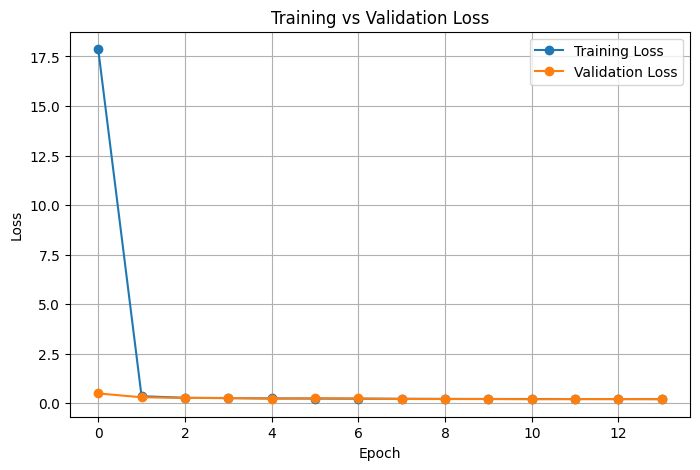

In [38]:
import matplotlib.pyplot as plt

# Extract loss and val_loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Create the plot
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

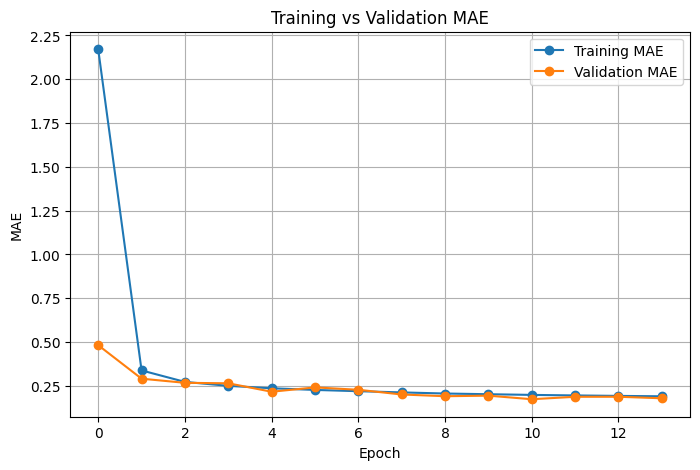

In [39]:
train_mae = history.history['mae']
val_mae = history.history['val_mae']

plt.figure(figsize=(8,5))
plt.plot(train_mae, label='Training MAE', marker='o')
plt.plot(val_mae, label='Validation MAE', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# ✅ 1️⃣ Make sure you have a test_dataset

test_dataset = (
    tf.data.TFRecordDataset(
        ["test-00000-of-00001.gz"], compression_type='GZIP'
    )
    .map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [41]:
#✅ 2️⃣ Evaluate your model on the test set

test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1943 - mae: 0.1733
Test Loss: 0.1899, Test MAE: 0.1722


In [42]:
# ✅ 3️⃣ Get predictions on the test set

y_pred = model.predict(test_dataset)

# y_pred is a NumPy array, one row per test example
print(y_pred.shape)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
(100000, 1)


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


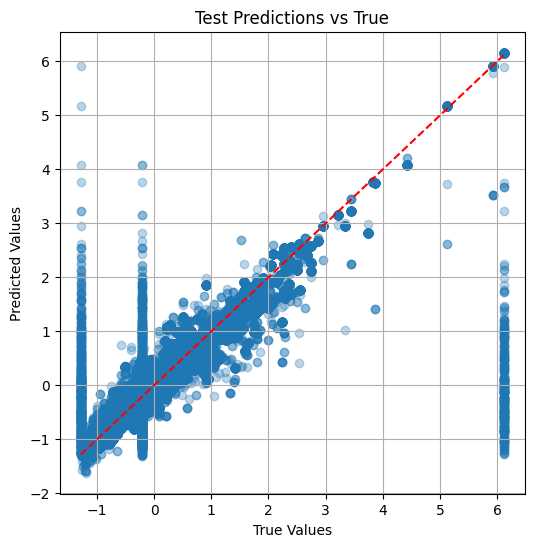

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Gather predictions & true labels
y_pred = model.predict(test_dataset)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Test Predictions vs True')
plt.grid(True)
plt.show()

In [44]:
model.save('my_laptop_prediction.keras')